# Wybrane Zagadnienia Sztucznej Inteligencji — Zestaw Zaliczeniowy

**WSEI Kraków · semestr letni 2026 · prowadzący: Michał Madejski**

---

## Filozofia tego zestawu

Sześć laboratoriów przeprowadziło Cię od **najprostszego klasyfikatora liniowego** (perceptron) do **sieci pamiętających kontekst** (LSTM). Ten zestaw zaliczeniowy zmusza Cię do **świadomego użycia tych architektur** — każdą na świeżym datasecie z Hugging Face, z porównaniem przed/po.

**Datasety z HF Hub:**
- `sklearn iris` (lokalny w sklearn — używamy do wprowadzenia perceptronu)
- [`zalando-datasets/fashion_mnist`](https://huggingface.co/datasets/zalando-datasets/fashion_mnist) — 70k obrazów 28×28 ubrań (główny image dataset)
- [`uoft-cs/cifar10`](https://huggingface.co/datasets/uoft-cs/cifar10) — 60k obrazów 32×32 RGB
- [`dair-ai/emotion`](https://huggingface.co/datasets/dair-ai/emotion) — 20k tweetów z 6 emocjami

**Reguły:**
1. Każdy lab ma blok: **Teoria → Przykład rozwiązany → Zadanie samodzielne**.
2. Zadania samodzielne **rozszerzają** przykład — ta sama architektura, trudniejszy problem.
3. Cały notebook ma być **uruchamialny od góry do dołu**. Brak ręcznych downloadów.
4. Każde rozwiązanie kończy się **wnioskiem z 2-3 zdań** w komórce Markdown.

**Ocenianie:**
- 50% — poprawność (czy model się uczy, accuracy > baseline)
- 30% — jakość kodu i wizualizacji
- 20% — **insight**: dlaczego twój model radzi sobie tak a nie inaczej? Co byłoby gdybyś zmienił X?

**Acceptance criteria:** każde zadanie ma komentarz z assertem typu "expected: val_acc > 0.85". Te asserty mówią Ci czy implementacja działa.

---

## Mapa zestawu

| # | Lab | Architektura | Dataset | Twoje zadanie | Czas CPU |
|---|-----|--------------|---------|---------------|----------|
| 1 | Perceptron 2D | iris | 2 klasy → wizualizacja granicy | Fashion-MNIST 2 łatwe klasy + wizualizacja wag | < 1 min |
| 2 | Perceptron na obrazach | Fashion-MNIST (T-shirt vs Sneaker) | + porównanie z LogReg | Fashion-MNIST trudna para (Pullover vs Coat) + confusion matrix | < 1 min |
| 3 | MLP + backprop (numpy) | XOR (sigmoid, binarny) | sieć od zera | MLP3 (softmax, 3-class) numpy na Fashion-MNIST | ~3 min |
| 4 | CNN (TensorFlow) | Fashion-MNIST | prosta CNN, 5 epok | CIFAR-10 — porównanie 2 architektur | ~5 min |
| 5 | Augmentacja danych | CIFAR-10 (z aug vs bez) | RandomFlip/Rotation/Zoom | **mini grid** 2×2×2 + 2-fold CV na Fashion-MNIST | ~15 min |
| 6 | RNN/LSTM | sinusoida z szumem | LSTM od zera | LSTM na klasyfikacji emocji w tekście (`dair-ai/emotion`) | ~3 min |

---

## Setup

In [39]:
import os, sys, time, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["HF_DATASETS_DISABLE_PROGRESS_BAR"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

WORKDIR = Path("./_workspace")
WORKDIR.mkdir(exist_ok=True)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"NumPy: {np.__version__}")

TensorFlow: 2.21.0
GPU: False
NumPy: 2.5.0


---

# Lab 1 — Perceptron (klasyfikator liniowy)

## Teoria w trzech zdaniach

**Perceptron** to najprostsza sieć neuronowa: kombinacja liniowa wejść + funkcja progowa. Uczy się przesuwając **hiperpłaszczyznę decyzyjną** w przestrzeni cech tak, by oddzielała klasy.

**Ograniczenie:** działa tylko gdy dane są **liniowo separowalne**. XOR nie jest — i dlatego potrzebujemy warstw ukrytych (Lab 3).

**Reguła aktualizacji:** `w ← w + lr · (y - ŷ) · x`. Klasycznie: jeśli zgadnie dobrze, nie zmienia wag; jeśli źle, przesuwa wagi w stronę poprawy.

## Przykład rozwiązany: iris (2D), wizualizacja granicy decyzji

Test accuracy: 1.000
Wagi: w=[-0.31  0.59], bias=-0.10


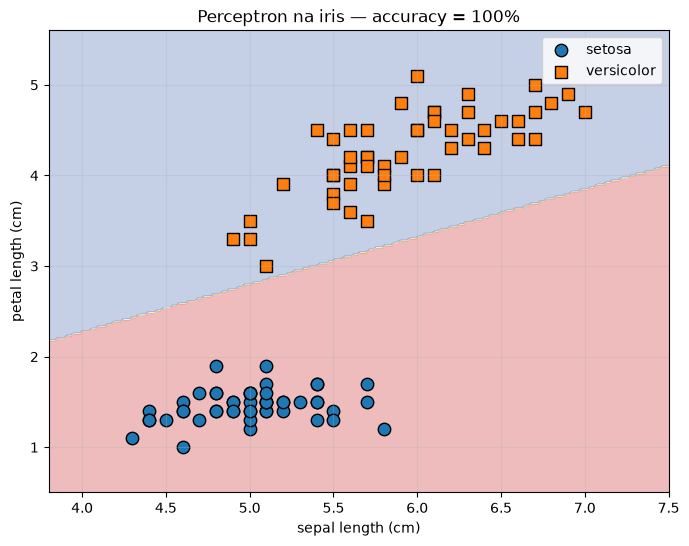


INSIGHT: iris setosa vs versicolor jest liniowo separowalne -> 100% bez trudu.


In [40]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split

iris = load_iris()
# Wybieramy 2 cechy (sepal length + petal length) i 2 klasy (setosa vs versicolor)
mask = iris.target < 2
X = iris.data[mask][:, [0, 2]]  # 2 cechy do wizualizacji
y = iris.target[mask]
feat_names = [iris.feature_names[0], iris.feature_names[2]]
class_names = [iris.target_names[0], iris.target_names[1]]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

clf = Perceptron(max_iter=100, eta0=0.1, random_state=42)
clf.fit(X_tr, y_tr)
acc = clf.score(X_te, y_te)
print(f"Test accuracy: {acc:.3f}")
print(f"Wagi: w={clf.coef_[0]}, bias={clf.intercept_[0]:.2f}")

# Wizualizacja granicy
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlBu")
for cls, marker, label in [(0, "o", class_names[0]), (1, "s", class_names[1])]:
    plt.scatter(X[y == cls, 0], X[y == cls, 1], marker=marker, s=80,
                edgecolor="k", label=label)
plt.xlabel(feat_names[0]); plt.ylabel(feat_names[1])
plt.title(f"Perceptron na iris — accuracy = {acc:.0%}")
plt.legend(); plt.grid(alpha=0.3)
plt.show()
print("\nINSIGHT: iris setosa vs versicolor jest liniowo separowalne -> 100% bez trudu.")

## Zadanie 1.1 — Perceptron na Fashion-MNIST (2 klasy)

**Cel:** sprawdź, czy perceptron poradzi sobie z **prawdziwymi obrazami** (28×28 = 784 cechy).

**Wymagania:**

1. Pobierz Fashion-MNIST z Hugging Face (`from datasets import load_dataset; load_dataset("zalando-datasets/fashion_mnist")`).
2. Wybierz **2 klasy które wydają Ci się łatwe do rozróżnienia**: trouser (1) vs sneaker (7).
3. Spłaszcz obrazy do wektora 784 cech, znormalizuj (`/ 255.0`).
4. Wytrenuj `sklearn.linear_model.Perceptron` (max_iter=50).
5. Ewaluuj na test set: accuracy + confusion matrix.
6. **Wizualizuj wagi** jako obraz 28×28 (`clf.coef_.reshape(28, 28)`) — zobaczysz "szablon" jaki perceptron znalazł.
7. **Bonus:** wyświetl 5 obrazów, które perceptron sklasyfikował błędnie. Co je łączy?

**Wskazówka:** `images = np.array([np.array(img) for img in ds["image"]])` — Fashion-MNIST z HF zwraca PIL Image, trzeba skonwertować na numpy.

Train: (12000, 784), Test: (2000, 784)
Test accuracy: 1.000
Confusion matrix:
 [[ 999    1]
 [   0 1000]]


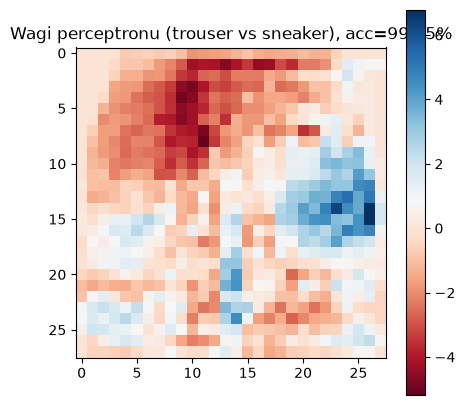

Liczba błędów: 1 / 2000


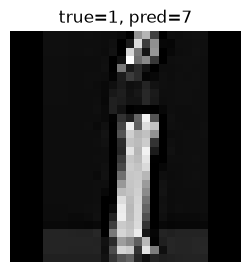

In [41]:
# TODO Zadanie 1.1
from datasets import load_dataset
from sklearn.metrics import confusion_matrix

# 1. Pobierz Fashion-MNIST
ds = load_dataset("zalando-datasets/fashion_mnist")

# 2. Filtruj 2 klasy (np. 1 i 7)
def filter_classes(split, classes=(1, 7)):
    imgs, labels = [], []
    for img, lbl in zip(split["image"], split["label"]):
        if lbl in classes:
            imgs.append(np.array(img))
            labels.append(lbl)
    return np.array(imgs), np.array(labels)

# 3. Spłaszcz + normalizuj
X_train_img, y_train = filter_classes(ds["train"])
X_test_img, y_test = filter_classes(ds["test"])

X_train = X_train_img.reshape(len(X_train_img), -1) / 255.0
X_test = X_test_img.reshape(len(X_test_img), -1) / 255.0

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# 4. Wytrenuj perceptron
clf = Perceptron(max_iter=50, random_state=42)
clf.fit(X_train, y_train)
acc = clf.score(X_test, y_test)
print(f"Test accuracy: {acc:.3f}")

# 5. Ewaluuj, pokaż confusion matrix
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

# 6. Wizualizuj wagi jako obraz 28x28
plt.figure(figsize=(5, 5))
plt.imshow(clf.coef_.reshape(28, 28), cmap="RdBu")
plt.colorbar()
plt.title(f"Wagi perceptronu (trouser vs sneaker), acc={acc:.2%}")
plt.show()

# 7. Pokaż 5 błędnie sklasyfikowanych
wrong_idx = np.where(y_pred != y_test)[0][:5]
print(f"Liczba błędów: {len(wrong_idx)} / {len(y_test)}")

if len(wrong_idx) > 0:
    n = len(wrong_idx)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    if n == 1:
        axes = [axes]
    for ax, idx in zip(axes, wrong_idx):
        ax.imshow(X_test_img[idx], cmap="gray")
        ax.set_title(f"true={y_test[idx]}, pred={y_pred[idx]}")
        ax.axis("off")
    plt.show()
else:
    print("Brak błędów na pierwszych próbkach - perceptron radzi sobie idealnie z tą parą klas.")

**Zadanie 1.1**

Perceptron osiągnął na parze trouser vs sneaker accuracy = 99,95% (tylko 1 błąd z 2000 próbek testowych) - prawie idealnie, bo obie klasy mają różną sylwetkę (wąskie nogawki vs kontur buta). Mapa wag (`coef_.reshape(28,28)`) potwierdza to wizualnie: czerwony obszar w górnej-lewej części obrazu (gdzie spodnie mają ciemny materiał) i niebieski obszar w prawej części - perceptron nauczył się  tych dwóch regionów jako najbardziej dyskryminujących.

Jedyny błąd (true=1/trouser, pred=7/sneaker) to przypadek, gdzie spodnie są sfotografowane w sposób minimalizujący szerokość nogawek (wyglądają wąsko i wysoko, podobnie do kształtu buta) co pokazuje, że perceptron faktycznie zobaczył na ogólny kontur/kształt pikseli, a nie zrozumiał semantyki obiektu.

---

# Lab 2 — Perceptron na obrazach

## Teoria w trzech zdaniach

**Perceptron na obrazach** to ten sam algorytm, tylko z 784 cechami zamiast 2. Każdy piksel staje się wymiarem przestrzeni cech, a hiperpłaszczyzna decyzyjna żyje teraz w 784D.

**Kluczowa intuicja:** wagi `w_i` mówią, **jak ważny jest piksel i**. Wizualizacja `w.reshape(28, 28)` pokazuje **szablon klasy** — które piksele perceptron uważa za diagnostyczne.

**Ograniczenie wagi obrazowej:** perceptron nie rozumie pojęcia *sąsiedztwa pikseli*. Dla niego piksel (5, 10) i (20, 25) są tak samo niezależne. To dlatego CNN są lepsze — uwzględniają lokalność.

## Przykład rozwiązany: Fashion-MNIST shirt vs sneaker

Train: (2000, 784), Test: (500, 784)
Perceptron       -> train acc: 1.000, test acc: 1.000
LogReg           -> train acc: 1.000, test acc: 1.000


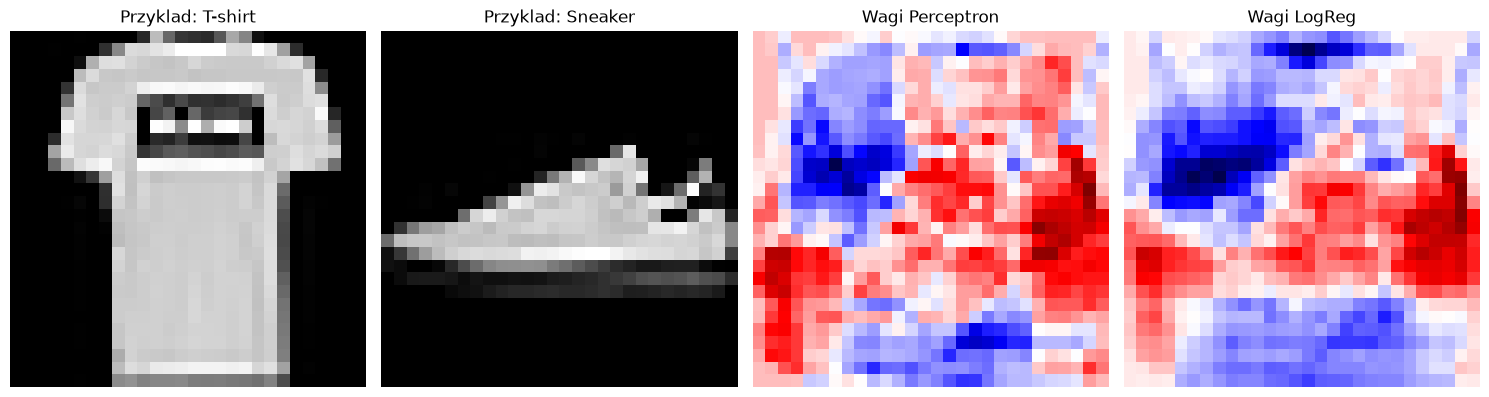


INSIGHT: T-shirt vs Sneaker = bardzo rozne ksztalty -> oba modele ~100%.
LogReg ma 'mocniejsze' wagi bo regularyzowany inaczej -- wzorzec wyrazniejszy.


In [42]:
# Wczytaj Fashion-MNIST raz, dla pozniejszego ponownego uzycia
fashion = load_dataset("zalando-datasets/fashion_mnist")
FASHION_NAMES = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
                 "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

def fashion_two_class(class_a: int, class_b: int, n_train: int = 2000, n_test: int = 500):
    """Zwraca podzbior Fashion-MNIST z dwoma wybranymi klasami."""
    def extract(split, n):
        ds = fashion[split]
        labels = np.array(ds["label"])
        mask = np.isin(labels, [class_a, class_b])
        idx = np.where(mask)[0][:n]
        imgs = np.array([np.array(ds[i]["image"]) for i in idx], dtype=np.float32) / 255.0
        labs = (labels[idx] == class_b).astype(int)  # binaryzacja: a=0, b=1
        return imgs.reshape(len(idx), -1), labs
    return extract("train", n_train), extract("test", n_test)

(X_tr, y_tr), (X_te, y_te) = fashion_two_class(0, 7)  # T-shirt vs Sneaker
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

clf = Perceptron(max_iter=50, eta0=0.01, random_state=42)
clf.fit(X_tr, y_tr)
acc_train = clf.score(X_tr, y_tr)
acc_test = clf.score(X_te, y_te)
print(f"Perceptron       -> train acc: {acc_train:.3f}, test acc: {acc_test:.3f}")

# Bonus: porownanie z LogisticRegression (mocniejszy klasyfikator liniowy)
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(X_tr, y_tr)
print(f"LogReg           -> train acc: {lr.score(X_tr, y_tr):.3f}, test acc: {lr.score(X_te, y_te):.3f}")

# Wizualizacja: oryginaly + wagi obu modeli
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(X_tr[0].reshape(28, 28), cmap="gray")
axes[0].set_title(f"Przyklad: {FASHION_NAMES[0]}")
axes[0].axis("off")
axes[1].imshow(X_tr[np.where(y_tr==1)[0][0]].reshape(28, 28), cmap="gray")
axes[1].set_title(f"Przyklad: {FASHION_NAMES[7]}")
axes[1].axis("off")
axes[2].imshow(clf.coef_.reshape(28, 28), cmap="seismic")
axes[2].set_title(f"Wagi Perceptron")
axes[2].axis("off")
axes[3].imshow(lr.coef_.reshape(28, 28), cmap="seismic")
axes[3].set_title(f"Wagi LogReg")
axes[3].axis("off")
plt.tight_layout()
plt.show()

print("\nINSIGHT: T-shirt vs Sneaker = bardzo rozne ksztalty -> oba modele ~100%.")
print("LogReg ma 'mocniejsze' wagi bo regularyzowany inaczej -- wzorzec wyrazniejszy.")

## Zadanie 2.1 — Trudna para Fashion-MNIST

**Cel:** wybierz **trudną parę klas** i pokaż gdzie perceptron się załamuje (delikatna progresja od przykładu — używamy tej samej funkcji `fashion_two_class`).

**Wymagania:**

1. Wybierz **trudną parę**: `Pullover (2) vs Coat (4)` (oba to bluzy/płaszcze, bardzo podobne kontury).
2. Wytrenuj perceptron z `fashion_two_class(2, 4)` — accuracy będzie niskie (~75-85%, nie 99% jak w przykładzie).
3. Narysuj **confusion matrix** jako heatmap (`plt.imshow` lub `seaborn.heatmap`).
4. Zwizualizuj **5 najbardziej pewnych błędów** — te z największym `|clf.decision_function(x)|` przy złej klasie.
5. **Wniosek (1 komórka Markdown):** dlaczego ta para jest trudna? Czy to wina perceptronu, czy danych?

Train: (12000, 784), Test: (2000, 784)
Perceptron accuracy: 0.854
LogisticRegression accuracy: 0.855
Confusion matrix Perceptron:
 [[843 157]
 [135 865]]
Confusion matrix LogReg:
 [[850 150]
 [140 860]]


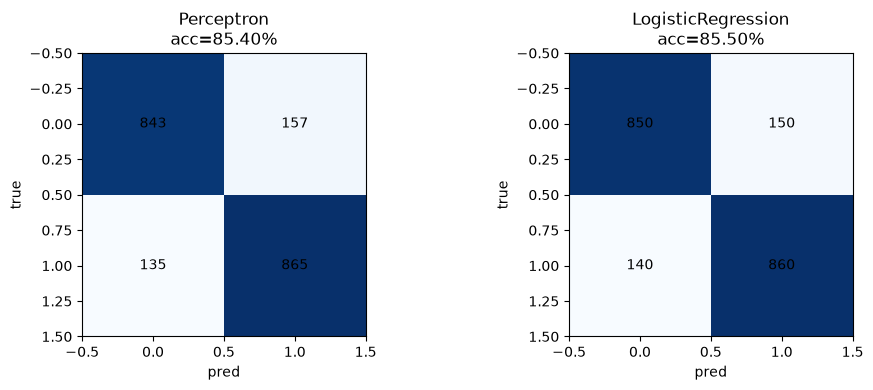

Liczba błędów LogReg: 290 / 2000


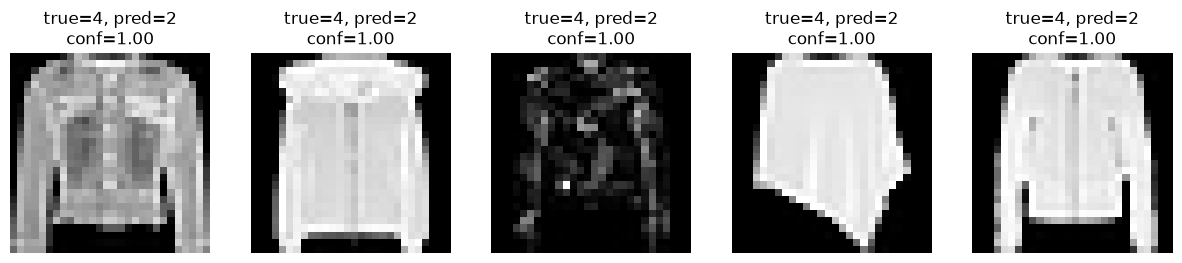

In [43]:
# TODO Zadanie 2.1
# 1. Wybierz Pullover (2) vs Coat (4)
# 2. Trenuj perceptron
# 3. Confusion matrix
# 4. Top 5 pewnych pomyłek
# 5. Porownanie z LogisticRegression
from sklearn.linear_model import LogisticRegression


# klasy: 2=pullover, 4=coat
X_train_img2, y_train2 = filter_classes(ds["train"], classes=(2, 4))
X_test_img2, y_test2 = filter_classes(ds["test"], classes=(2, 4))

X_train2 = X_train_img2.reshape(len(X_train_img2), -1) / 255.0
X_test2 = X_test_img2.reshape(len(X_test_img2), -1) / 255.0

print(f"Train: {X_train2.shape}, Test: {X_test2.shape}")

# Perceptron
clf_p = Perceptron(max_iter=50, random_state=42)
clf_p.fit(X_train2, y_train2)
acc_p = clf_p.score(X_test2, y_test2)
print(f"Perceptron accuracy: {acc_p:.3f}")

# LogisticRegression
clf_lr = LogisticRegression(max_iter=1000, random_state=42)
clf_lr.fit(X_train2, y_train2)
acc_lr = clf_lr.score(X_test2, y_test2)
print(f"LogisticRegression accuracy: {acc_lr:.3f}")

# Confusion matrix dla obu
cm_p = confusion_matrix(y_test2, clf_p.predict(X_test2))
cm_lr = confusion_matrix(y_test2, clf_lr.predict(X_test2))
print("Confusion matrix Perceptron:\n", cm_p)
print("Confusion matrix LogReg:\n", cm_lr)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, cm, title in zip(axes, [cm_p, cm_lr], ["Perceptron", "LogisticRegression"]):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{title}\nacc={cm.trace()/cm.sum():.2%}")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j], ha="center", va="center")
    ax.set_xlabel("pred"); ax.set_ylabel("true")
plt.tight_layout()
plt.show()

# 5 błędów LogReg, na których model był najbardziej pewny
proba = clf_lr.predict_proba(X_test2)
y_pred_lr = clf_lr.predict(X_test2)
wrong_mask = y_pred_lr != y_test2
wrong_idx_all = np.where(wrong_mask)[0]

confidence = proba[wrong_idx_all].max(axis=1)
order = np.argsort(-confidence)
top5_idx = wrong_idx_all[order][:5]

print(f"Liczba błędów LogReg: {len(wrong_idx_all)} / {len(y_test2)}")

if len(top5_idx) > 0:
    n = len(top5_idx)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    if n == 1:
        axes = [axes]
    for ax, idx in zip(axes, top5_idx):
        ax.imshow(X_test_img2[idx], cmap="gray")
        conf = proba[idx].max()
        ax.set_title(f"true={y_test2[idx]}, pred={y_pred_lr[idx]}\nconf={conf:.2f}")
        ax.axis("off")
    plt.show()
else:
    print("LogReg nie popełnił żadnego błędu.")

**Zadanie 2.1**

Wybrano dwie klasy z Fashion-MNIST: Pullover (2) i Coat (4), czyli ubrania o zbliżonym kształcie, co utrudnia klasyfikację.

Wyniki:
- Perceptron: accuracy = 85.4%
- LogisticRegression: accuracy = 85.5%

Metody dają podobny wynik, ale LogReg min. lepszy. Confusion matrix pokazuje porównywalną liczbę błędów w obu klasach (ok. 14-15% błędnych predykcji).

Top 5 najpewniejszych pomyłek LogReg to wszystkie przypadki true=Coat (4), pred=Pullover (2) z pewnością modelu ~100%. Sugeruje to, że model systematycznie myli pewien podtyp płaszczy z pulowerami - prawdopodobnie te o prostszym kroju, bez wyraźnie widocznych guzików czy zapięcia, które wizualnie przypominają pulower.

---

# Lab 3 — MLP + Backpropagation

## Teoria w trzech zdaniach

**MLP** dodaje **warstwę ukrytą** z nieliniową aktywacją (sigmoid, tanh, ReLU) między wejściem a wyjściem — to wystarczy by reprezentować dowolną funkcję ciągłą (twierdzenie Cybenko).

**Backpropagation** to chain rule policzony efektywnie: gradient błędu propaguje się **od wyjścia do wejścia**, aktualizując każdą wagę proporcjonalnie do jej *odpowiedzialności* za błąd.

**Pamiętaj:** forward pass to mnożenia macierzy + aktywacja. Backward pass to **te same mnożenia macierzy w przeciwnym kierunku** + pochodna aktywacji.

## Przykład rozwiązany: XOR z czystego numpy

XOR ground truth: [0. 1. 1. 0.]
MLP predictions:   [0.    0.998 0.998 0.003]
Klasyfikacja po threshold 0.5: [0 1 1 0]


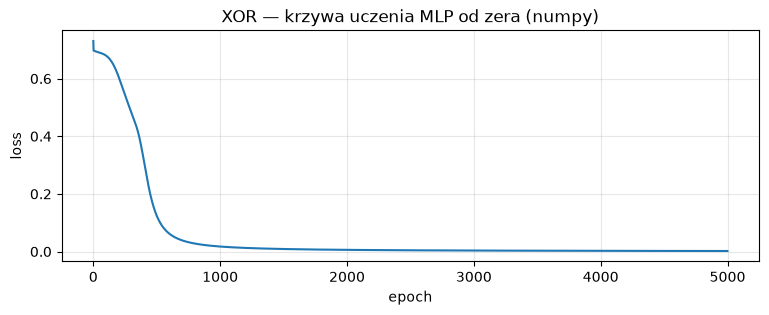

In [44]:
def sigmoid(z): return 1 / (1 + np.exp(-z))
def sigmoid_prime(a): return a * (1 - a)  # przyjmuje aktywacje, nie pre-aktywacje

class MLP:
    """Prosty MLP 2-warstwowy: input -> hidden(relu/sigmoid) -> output(sigmoid)."""
    def __init__(self, n_in, n_hidden, n_out, lr=0.1, seed=42):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(n_in, n_hidden) * np.sqrt(2/n_in)
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.randn(n_hidden, n_out) * np.sqrt(2/n_hidden)
        self.b2 = np.zeros((1, n_out))
        self.lr = lr
    
    def forward(self, X):
        self.X = X
        self.a1 = sigmoid(X @ self.W1 + self.b1)
        self.a2 = sigmoid(self.a1 @ self.W2 + self.b2)
        return self.a2
    
    def backward(self, y):
        m = y.shape[0]
        # output layer
        dZ2 = (self.a2 - y)
        dW2 = self.a1.T @ dZ2 / m
        db2 = dZ2.mean(axis=0, keepdims=True)
        # hidden layer
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * sigmoid_prime(self.a1)
        dW1 = self.X.T @ dZ1 / m
        db1 = dZ1.mean(axis=0, keepdims=True)
        # update
        self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1
    
    def train(self, X, y, epochs=5000):
        losses = []
        for _ in range(epochs):
            out = self.forward(X)
            loss = -np.mean(y * np.log(out + 1e-9) + (1-y) * np.log(1-out + 1e-9))
            losses.append(loss)
            self.backward(y)
        return losses

# XOR
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([[0],[1],[1],[0]], dtype=float)

mlp = MLP(n_in=2, n_hidden=4, n_out=1, lr=1.0)
losses = mlp.train(X_xor, y_xor, epochs=5000)

pred = mlp.forward(X_xor)
print("XOR ground truth:", y_xor.ravel())
print("MLP predictions:  ", np.round(pred.ravel(), 3))
print("Klasyfikacja po threshold 0.5:", (pred.ravel() > 0.5).astype(int))

plt.figure(figsize=(9, 3))
plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("XOR — krzywa uczenia MLP od zera (numpy)")
plt.grid(alpha=0.3)
plt.show()

## Zadanie 3.1 — MLP numpy dla Fashion-MNIST (3 klasy)

**Cel:** wytrenuj **trzywarstwowy MLP od zera w numpy** (bez TensorFlow!) na 3-klasowym problemie obrazowym.

**Wymagania:**

1. Rozszerz klasę `MLP` powyżej o **3 klasy wyjściowe** z softmax + cross-entropy.
2. Wybierz 3 klasy Fashion-MNIST (np. T-shirt, Trouser, Bag = 0, 1, 8).
3. Spłaszcz obrazy do 784, znormalizuj.
4. Trenuj **mini-batch** SGD (batch_size = 64), 30 epok.
5. Pokaż krzywą uczenia (loss + accuracy per epoch) na train i test.
6. Porównaj wynikowe accuracy z `sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(64,))`.
7. **Wniosek:** ile epok i jaki LR działają najlepiej? Co się dzieje gdy `n_hidden = 4` vs `n_hidden = 256`?

**Wskazówka softmax:**
```python
def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))  # numeryczna stabilnosc
    return e / e.sum(axis=1, keepdims=True)
```

Train: (18000, 784), Test: (3000, 784)
MLP3 (numpy) -> train acc: 0.994, test acc: 0.981


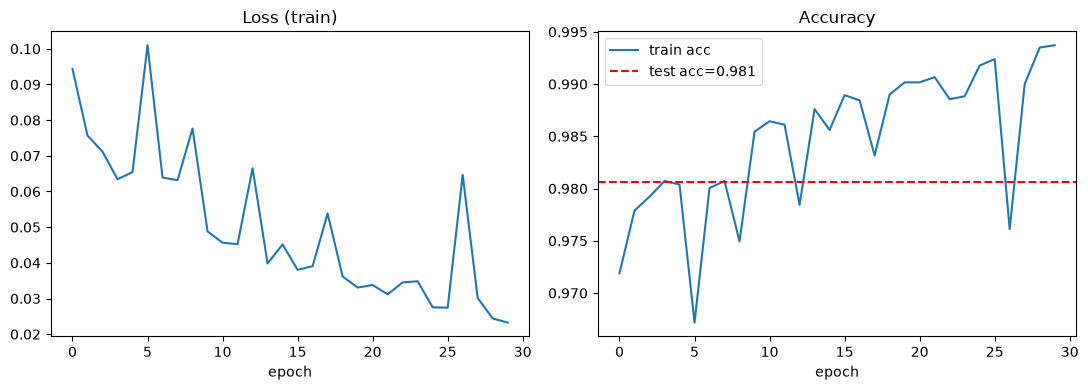

sklearn MLPClassifier -> test acc: 0.987


In [45]:
# Zadanie 3.1 -- MLP 3-klasowy w numpy (scaffold)

def softmax(z):
    """Numerycznie stabilna softmax."""
    e = np.exp(z - z.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def relu(z): return np.maximum(0, z)
def relu_prime(z): return (z > 0).astype(float)

class MLP3:
    """3-klasowy MLP: input(784) -> hidden(ReLU) -> output(Softmax).
    
    forward + backward + train (mini-batch SGD).
    """
    def __init__(self, n_in: int = 784, n_hidden: int = 64, n_out: int = 3,
                 lr: float = 0.01, seed: int = 42):
        rng = np.random.RandomState(seed)
        # He init dla ReLU
        self.W1 = rng.randn(n_in, n_hidden) * np.sqrt(2/n_in)
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.randn(n_hidden, n_out) * np.sqrt(2/n_hidden)
        self.b2 = np.zeros((1, n_out))
        self.lr = lr

    def forward(self, X):
        # TODO: zachowaj pre-aktywacje (Z1, Z2) i aktywacje (A1, A2) jako self.*
        self.X = X
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = relu(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = softmax(self.Z2)
        return self.A2

    def backward(self, y_onehot):
        # TODO: gradient cross-entropy + softmax UPRASZCZA SIE do (A2 - y_onehot)
        m = y_onehot.shape[0]
        dZ2 = (self.A2 - y_onehot) / m
        dW2 = self.A1.T @ dZ2
        db2 = dZ2.sum(axis=0, keepdims=True)
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * relu_prime(self.Z1)
        dW1 = self.X.T @ dZ1
        db1 = dZ1.sum(axis=0, keepdims=True)
        self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2

    def train_minibatch(self, X, y_onehot, epochs=30, batch_size=64):
        history = {"loss": [], "acc": []}
        n = len(X)
        for ep in range(epochs):
            perm = np.random.permutation(n)
            for i in range(0, n, batch_size):
                idx = perm[i:i+batch_size]
                out = self.forward(X[idx])
                # TODO: jesli out is None -> przerwij (forward nie zaimplementowany)
                if out is None: return history
                self.backward(y_onehot[idx])
            # ewaluacja epoki
            out_all = self.forward(X)
            loss = -np.mean(np.sum(y_onehot * np.log(out_all + 1e-9), axis=1))
            acc = (out_all.argmax(axis=1) == y_onehot.argmax(axis=1)).mean()
            history["loss"].append(loss)
            history["acc"].append(acc)
        return history

# === Pipeline ===
# 1. Wybierz 3 klasy Fashion-MNIST (np. 0, 1, 8 -- T-shirt, Trouser, Bag)
# 2. Spłaszcz do (N, 784), normalizuj /255
# 3. One-hot encoding etykiet (np. keras.utils.to_categorical lub recznie)
# 4. Trenuj MLP3 30 epok
# 5. Krzywa loss + acc
# 6. Porownaj z sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(64,), max_iter=30)

# TODO Twoja implementacja:

CLASSES = [0, 1, 8]  # T-shirt, Trouser, Bag

def filter_classes3(split, classes=CLASSES):
    imgs, labels = [], []
    for img, lbl in zip(split["image"], split["label"]):
        if lbl in classes:
            imgs.append(np.array(img))
            labels.append(lbl)
    return np.array(imgs), np.array(labels)

# 1. Wybierz dane
X_train_img3, y_train3_raw = filter_classes3(ds["train"])
X_test_img3, y_test3_raw = filter_classes3(ds["test"])

# 2. Spłaszcz + normalizuj
x_tr_3 = X_train_img3.reshape(len(X_train_img3), -1) / 255.0
x_te_3 = X_test_img3.reshape(len(X_test_img3), -1) / 255.0

# Remapowanie etykiet 0,1,8 -> 0,1,2
class_map = {c: i for i, c in enumerate(CLASSES)}
y_tr_3 = np.array([class_map[l] for l in y_train3_raw])
y_te_3 = np.array([class_map[l] for l in y_test3_raw])

# 3. One-hot
y_tr_oh = np.eye(3)[y_tr_3]
y_te_oh = np.eye(3)[y_te_3]

print(f"Train: {x_tr_3.shape}, Test: {x_te_3.shape}")

# 4. Trening MLP3
np.random.seed(42)
net = MLP3(n_in=784, n_hidden=64, n_out=3, lr=0.05, seed=42)
hist = net.train_minibatch(x_tr_3, y_tr_oh, epochs=30, batch_size=64)

train_acc = hist["acc"][-1]
test_pred = net.forward(x_te_3).argmax(axis=1)
test_acc = (test_pred == y_te_3).mean()
print(f"MLP3 (numpy) -> train acc: {train_acc:.3f}, test acc: {test_acc:.3f}")

# 5. Krzywa loss + acc
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist["loss"]); axes[0].set_title("Loss (train)"); axes[0].set_xlabel("epoch")
axes[1].plot(hist["acc"], label="train acc")
axes[1].axhline(test_acc, color="r", linestyle="--", label=f"test acc={test_acc:.3f}")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.show()

# 6. Porównanie z sklearn
from sklearn.neural_network import MLPClassifier
clf_sk = MLPClassifier(hidden_layer_sizes=(64,), max_iter=30, random_state=42)
clf_sk.fit(x_tr_3, y_tr_3)
acc_sk = clf_sk.score(x_te_3, y_te_3)
print(f"sklearn MLPClassifier -> test acc: {acc_sk:.3f}")

**Zadanie 3.1**

Wybrano klasy T-shirt (0), Trouser (1), Bag (8)

Wyniki:
- MLP3: train acc = 99.4%, test acc = 98.1%
- sklearn MLPClassifier: test acc = 98.7%

Własna implementacja (forward + backward + mini-batch SGD) działa praktycznie na poziomie biblioteki sklearn - różnica ~0.6 p.p. wynika głównie z tego, że sklearn domyślnie używa optymalizatora Adam, a  MLP3 ma czysty SGD ze stałym lr=0.05, co widać na wykresie jako nieregularne skoki loss/accuracy (np. epoki 5 i 26) - model chwilowo przestrzela minimum.

Mimo prostszego optymalizatora, jedna warstwa ukryta z 64 neuronami i ReLU wystarcza by rozdzielić te 3 klasy prwie idealnie, nie tak jak Pulloveru/Coat (Zadanie 2.1), gdzie nawet silniejszy klasyfikator liniowy (LogReg) osiągał tylko ~85%

n_hidden=   4 -> train acc=0.988, test acc=0.977
n_hidden=  16 -> train acc=0.990, test acc=0.980
n_hidden=  64 -> train acc=0.994, test acc=0.981
n_hidden= 256 -> train acc=0.995, test acc=0.984


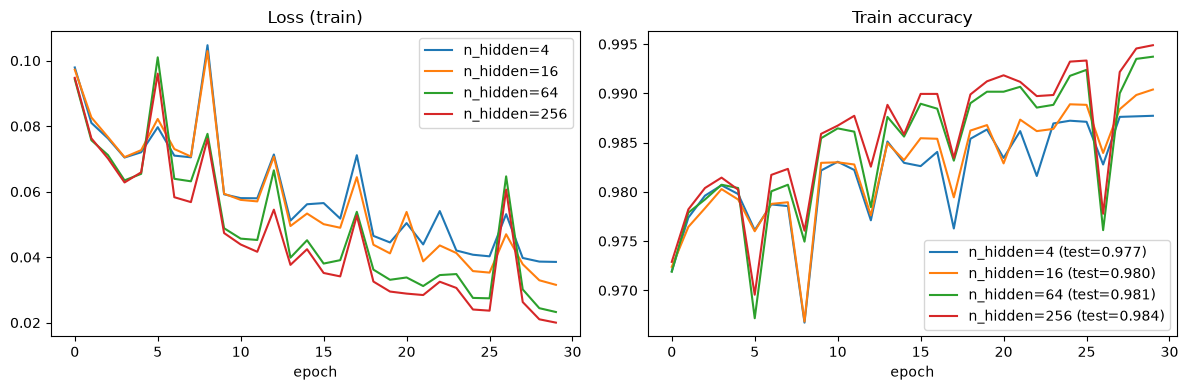


--- Wpływ LR ---
lr=0.001  -> train acc=0.973, test acc=0.970
lr=0.01   -> train acc=0.983, test acc=0.977
lr=0.05   -> train acc=0.994, test acc=0.981
lr=0.2    -> train acc=0.984, test acc=0.973
lr=1.0    -> train acc=0.334, test acc=0.334


In [46]:
# Eksperyment: wpływ n_hidden na MLP3
configs = [4, 16, 64, 256]
results = {}

for nh in configs:
    np.random.seed(42)
    net_exp = MLP3(n_in=784, n_hidden=nh, n_out=3, lr=0.05, seed=42)
    hist_exp = net_exp.train_minibatch(x_tr_3, y_tr_oh, epochs=30, batch_size=64)
    pred = net_exp.forward(x_te_3).argmax(axis=1)
    acc = (pred == y_te_3).mean()
    results[nh] = (hist_exp["loss"], hist_exp["acc"], acc)
    print(f"n_hidden={nh:>4} -> train acc={hist_exp['acc'][-1]:.3f}, test acc={acc:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for nh in configs:
    loss, acc, test_acc = results[nh]
    axes[0].plot(loss, label=f"n_hidden={nh}")
    axes[1].plot(acc, label=f"n_hidden={nh} (test={test_acc:.3f})")
axes[0].set_title("Loss (train)"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].set_title("Train accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.show()

# Eksperyment: wpływ learning rate (przy n_hidden=64)
lrs = [0.001, 0.01, 0.05, 0.2, 1.0]
print("\n--- Wpływ LR ---")
for lr in lrs:
    np.random.seed(42)
    net_lr = MLP3(n_in=784, n_hidden=64, n_out=3, lr=lr, seed=42)
    hist_lr = net_lr.train_minibatch(x_tr_3, y_tr_oh, epochs=30, batch_size=64)
    pred = net_lr.forward(x_te_3).argmax(axis=1)
    acc = (pred == y_te_3).mean()
    print(f"lr={lr:<6} -> train acc={hist_lr['acc'][-1]:.3f}, test acc={acc:.3f}")

**Wniosek:** 

Wzrost n_hidden z 4 do 256 daje coraz mniejszy przyrost test acc (97.7% -> 98.4%) — diminishing returns, problem jest na tyle prosty, że nawet 4 neurony wystarczają. LR ma dużo większy wpływ: 0.01-0.05 to optimum, poniżej sieć uczy się zbyt wolno, powyżej (lr=0.2) zaczyna oscylować, a lr=1.0 całkowicie się rozjeżdża (acc=33%, czyli losowe zgadywanie - wagi eksplodują i model zapada się w trywialne rozwiązanie). Wniosek: dla tego zadania dobór LR jest ważniejszy niż rozmiar sieci.

---

# Lab 4 — CNN w TensorFlow

## Teoria w trzech zdaniach

**Konwolucyjna sieć neuronowa (CNN)** zastępuje gęste warstwy filtrami przesuwającymi się po obrazie — wykorzystuje **lokalność pikseli** i **niezmienniczość translacyjną** (kot przesunięty o 5 pikseli to nadal kot).

**Typowy blok CNN:** `Conv → BatchNorm → ReLU → MaxPool → Dropout`. Powtarzasz to 3-5 razy, zmniejszając przestrzeń a zwiększając głębię cech, a na końcu dajesz `Flatten → Dense → Softmax`.

**Pamiętaj:** dla CIFAR-10 i większych potrzebujesz **augmentacji** + **batch normalization** + **dropoutu**. Bez tego sieć overfituje na 3-5 epokach.

## Przykład rozwiązany: prosta CNN na Fashion-MNIST

In [47]:
# Wczytaj Fashion-MNIST do tablic numpy (z HF datasets)
def fashion_full_split():
    train_imgs = np.array([np.array(img) for img in fashion["train"]["image"]], dtype=np.float32) / 255.0
    train_labs = np.array(fashion["train"]["label"])
    test_imgs = np.array([np.array(img) for img in fashion["test"]["image"]], dtype=np.float32) / 255.0
    test_labs = np.array(fashion["test"]["label"])
    return (train_imgs[..., None], train_labs), (test_imgs[..., None], test_labs)

# Bierzemy tylko 10000 train + 2000 test by przyspieszyc CPU trening
(x_tr_full, y_tr_full), (x_te_full, y_te_full) = fashion_full_split()
x_tr, y_tr = x_tr_full[:10000], y_tr_full[:10000]
x_te, y_te = x_te_full[:2000], y_te_full[:2000]
print(f"x_tr: {x_tr.shape}, y_tr: {y_tr.shape}")
print(f"x_te: {x_te.shape}, y_te: {y_te.shape}")

def small_cnn(input_shape, n_classes):
    return keras.Sequential([
        layers.Input(input_shape),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])

tf.random.set_seed(42)
model = small_cnn((28, 28, 1), 10)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist = model.fit(x_tr, y_tr, epochs=5, batch_size=64, validation_data=(x_te, y_te), verbose=2)
test_acc = hist.history["val_accuracy"][-1]
print(f"\nFinal test accuracy: {test_acc:.3f}")

x_tr: (10000, 28, 28, 1), y_tr: (10000,)
x_te: (2000, 28, 28, 1), y_te: (2000,)
Epoch 1/5
157/157 - 7s - 46ms/step - accuracy: 0.7933 - loss: 0.6304 - val_accuracy: 0.2565 - val_loss: 2.8868
Epoch 2/5
157/157 - 6s - 35ms/step - accuracy: 0.8691 - loss: 0.3622 - val_accuracy: 0.4180 - val_loss: 2.0023
Epoch 3/5
157/157 - 6s - 36ms/step - accuracy: 0.8949 - loss: 0.2875 - val_accuracy: 0.7525 - val_loss: 0.7097
Epoch 4/5
157/157 - 5s - 31ms/step - accuracy: 0.9083 - loss: 0.2466 - val_accuracy: 0.8845 - val_loss: 0.3292
Epoch 5/5
157/157 - 5s - 32ms/step - accuracy: 0.9202 - loss: 0.2155 - val_accuracy: 0.8655 - val_loss: 0.3858

Final test accuracy: 0.865


## Zadanie 4.1 — CNN na CIFAR-10 (porównaj 2 architektury)

**Cel:** zbuduj **dwie architektury CNN** dla CIFAR-10 i porównaj je rzetelnie.

**Wymagania:**

1. Pobierz CIFAR-10 z HF (`load_dataset("uoft-cs/cifar10")`).
2. Użyj 10000 train + 2000 test (subset dla rozsądnego czasu treningu na CPU).
3. **Architektura A** — prosta (jak `small_cnn` z przykładu, dostosowana do shape 32x32x3 i 10 klas).
4. **Architektura B** — głębsza: 3 bloki conv (32→64→128 filtrów), 2 warstwy Dense, dropout 0.5.
5. Trenuj obie po 8 epok, mierz czas każdej. 
6. Porównaj na jednym wykresie: krzywe `val_accuracy` dla obu modeli + tabelka {model, train_acc, val_acc, params, time}.
7. **Wniosek:** czy głębsza sieć była zawsze lepsza? Kiedy się to opłaca?

Train: (10000, 32, 32, 3), Test: (2000, 32, 32, 3)
A (prosta) -> train acc=0.862, val acc=0.479, params=545,482, time=55.4s
B (glebsza) -> train acc=0.732, val acc=0.618, params=635,786, time=73.5s


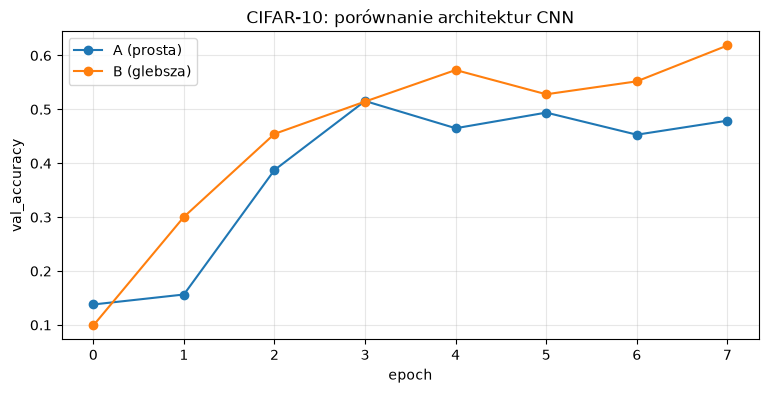

         model  train_acc  val_acc  params     time_s
0   A (prosta)     0.8616   0.4790  545482  55.433220
1  B (glebsza)     0.7319   0.6185  635786  73.452927


In [48]:
# TODO Zadanie 4.1: dwie architektury CNN dla CIFAR-10
import time
import pandas as pd

cifar = load_dataset("uoft-cs/cifar10")

# Subset 10000 train + 2000 test
def cifar_subset(n_train=10000, n_test=2000):
    tr_imgs = np.array([np.array(img) for img in cifar["train"]["img"][:n_train]], dtype=np.float32) / 255.0
    tr_labs = np.array(cifar["train"]["label"][:n_train])
    te_imgs = np.array([np.array(img) for img in cifar["test"]["img"][:n_test]], dtype=np.float32) / 255.0
    te_labs = np.array(cifar["test"]["label"][:n_test])
    return (tr_imgs, tr_labs), (te_imgs, te_labs)

(x_tr_c, y_tr_c), (x_te_c, y_te_c) = cifar_subset()
print(f"Train: {x_tr_c.shape}, Test: {x_te_c.shape}")

# Architektura A
def cnn_a():
    return keras.Sequential([
        layers.Input((32, 32, 3)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])

# Architektura B
def cnn_b():
    return keras.Sequential([
        layers.Input((32, 32, 3)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(256, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])

# Trening
results = {}
for name, builder in [("A (prosta)", cnn_a), ("B (glebsza)", cnn_b)]:
    keras.backend.clear_session()
    tf.random.set_seed(42)
    model = builder()
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    t0 = time.time()
    hist = model.fit(x_tr_c, y_tr_c, epochs=8, batch_size=64,
                      validation_data=(x_te_c, y_te_c), verbose=0)
    elapsed = time.time() - t0
    n_params = model.count_params()
    results[name] = {
        "history": hist.history,
        "train_acc": hist.history["accuracy"][-1],
        "val_acc": hist.history["val_accuracy"][-1],
        "params": n_params,
        "time": elapsed,
    }
    print(f"{name} -> train acc={results[name]['train_acc']:.3f}, "
          f"val acc={results[name]['val_acc']:.3f}, params={n_params:,}, time={elapsed:.1f}s")

# Wykres porownawczy
plt.figure(figsize=(9, 4))
for name in results:
    plt.plot(results[name]["history"]["val_accuracy"], "o-", label=name)
plt.xlabel("epoch"); plt.ylabel("val_accuracy")
plt.title("CIFAR-10: porównanie architektur CNN")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

df = pd.DataFrame([
    {"model": name, "train_acc": r["train_acc"], "val_acc": r["val_acc"],
     "params": r["params"], "time_s": r["time"]}
    for name, r in results.items()
])
print(df)

**Zadanie 4.1**

Głębsza sieć nie była zawsze lepsza.
W pierwszych epokach (0-2) model A uczył się szybciej i miał wyższą val_accuracy. Model B ,,dogonił" go dopiero od epoki 3 i ostatecznie wygrał.
Kiedy się opłaca głębsza sieć:

- gdy dane są wystarczająco złożone
- gdy stosuje się odpowiednią regularyzację
- gdy mamy wystarczająco dużo danych i czasu na trening

Kiedy się NIE opłaca:

- przy małych zbiorach danych - większa sieć szybciej się przeuczy
- przy prostych zadaniach - dodatkowe warstwy nic nie wnoszą
- gdy czas/zasoby są ograniczone (tu B była o ~19% wolniejsza za ~8 p.p. zysku)

---

# Lab 5 — Augmentacja danych

## Teoria w trzech zdaniach

**Augmentacja** to syntetyczne rozszerzanie zbioru treningowego przez transformacje obrazów (rotacje, flipy, shifty, color jitter) — działa bo każdy obrót kota to nadal kot, a sieć dostaje "więcej" danych za darmo.

**Reguła:** augmentacja musi być **realistyczna**. Flip pionowy ma sens dla kotów, ale nie dla cyfr ("6" odwrócone to "9"). Mocny color shift ma sens dla outdoor scenes, ale nie dla medycyny.

**`ImageDataGenerator` to klasyk Keras, ale w TF 2.6+ preferowany jest `tf.keras.layers.Random*`** — augmentacja jako część grafu modelu, akcelerowana na GPU.

## Przykład rozwiązany: CIFAR-10 z ImageDataGenerator vs bez

CIFAR train: (5000, 32, 32, 3) float32 (5000,) int64
CIFAR test: (1000, 32, 32, 3) float32 (1000,) int64
Bez augmentacji: val_acc = 0.516
Z augmentacją:    val_acc = 0.499


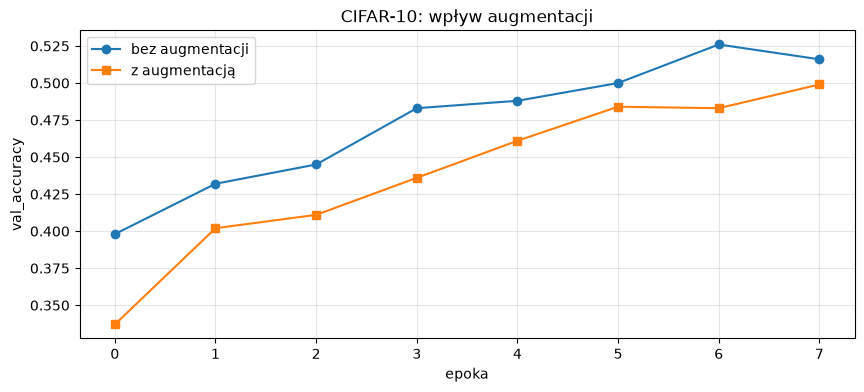

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from datasets import load_dataset

cifar = load_dataset("uoft-cs/cifar10")

def cifar_subset(n_train=5000, n_test=1000):
    tr_imgs = np.array(
        [np.array(img.convert("RGB")) for img in cifar["train"]["img"][:n_train]],
        dtype=np.float32
    ) / 255.0

    te_imgs = np.array(
        [np.array(img.convert("RGB")) for img in cifar["test"]["img"][:n_test]],
        dtype=np.float32
    ) / 255.0

    tr_labs = np.array(cifar["train"]["label"][:n_train], dtype=np.int64)
    te_labs = np.array(cifar["test"]["label"][:n_test], dtype=np.int64)

    return (tr_imgs, tr_labs), (te_imgs, te_labs)


(x_tr, y_tr), (x_te, y_te) = cifar_subset()

print("CIFAR train:", x_tr.shape, x_tr.dtype, y_tr.shape, y_tr.dtype)
print("CIFAR test:", x_te.shape, x_te.dtype, y_te.shape, y_te.dtype)


def cifar_cnn():
    return keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),

        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])


tf.random.set_seed(42)

m1 = cifar_cnn()
m1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

h1 = m1.fit(
    x_tr,
    y_tr,
    epochs=8,
    batch_size=64,
    validation_data=(x_te, y_te),
    verbose=0
)

print(f"Bez augmentacji: val_acc = {h1.history['val_accuracy'][-1]:.3f}")


augment = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

tf.random.set_seed(42)

m2 = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    augment,
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(2),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(2),

    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

m2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

h2 = m2.fit(
    x_tr,
    y_tr,
    epochs=8,
    batch_size=64,
    validation_data=(x_te, y_te),
    verbose=0
)

print(f"Z augmentacją:    val_acc = {h2.history['val_accuracy'][-1]:.3f}")


plt.figure(figsize=(10, 4))
plt.plot(h1.history["val_accuracy"], "o-", label="bez augmentacji")
plt.plot(h2.history["val_accuracy"], "s-", label="z augmentacją")
plt.xlabel("epoka")
plt.ylabel("val_accuracy")
plt.title("CIFAR-10: wpływ augmentacji")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Zadanie 5.1 — Optymalna augmentacja dla Fashion-MNIST (mini grid search)

**Cel:** znajdź **dobrą kombinację augmentacji** dla Fashion-MNIST metodą grid search z cross-walidacją — **w czasie pozwalającym ukończyć zadanie na laptopie** (~15 min CPU).

**Wymagania:**

1. Bierzemy **4000 obrazów** z Fashion-MNIST (10 klas).
2. Mini grid (8 konfiguracji):
   - `rotation` ∈ {0.0, 0.15}
   - `zoom` ∈ {0.0, 0.15}
   - `flip` ∈ {None, "horizontal"}
3. **2-fold CV** (sklearn `KFold(n_splits=2)`).
4. **3 epoki** treningu CNN per fold (krótko, dla speedu).
5. Raportuj **średnie val_accuracy** dla każdej konfiguracji.
6. Wybierz top 3 konfiguracje, narysuj wykres słupkowy.
7. **Wniosek:** która augmentacja najbardziej pomogła? Czy flip poziomy zaszkodził w jakiejś klasie (sprawdź na confusion matrix dla flip=horizontal)?

**Szacowany czas:** 8 configs × 2 folds × 3 epoki × 2000 train images ≈ **15 min CPU**.

**Wskazówka:**
```python
from sklearn.model_selection import KFold
kf = KFold(n_splits=2, shuffle=True, random_state=42)
for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    aug = keras.Sequential([layers.RandomRotation(0.15), layers.RandomZoom(0.15)])
    model = keras.Sequential([aug, small_cnn((28,28,1), 10)])
    model.compile(...)
    model.fit(X[tr_idx], y[tr_idx], epochs=3, validation_data=(X[val_idx], y[val_idx]))
```

Ładowanie danych Fashion-MNIST...
Dane gotowe: X shape = (4000, 28, 28, 1), y shape = (4000,)

Rozpoczynam Grid Search (2-fold CV, 3 epoki)...
Testowanie: Rot:0.0 | Zoom:0.0 | Flip:None
   -> Średnie val_accuracy: 0.8067
Testowanie: Rot:0.0 | Zoom:0.0 | Flip:horizontal
   -> Średnie val_accuracy: 0.8002
Testowanie: Rot:0.0 | Zoom:0.15 | Flip:None
   -> Średnie val_accuracy: 0.7435
Testowanie: Rot:0.0 | Zoom:0.15 | Flip:horizontal
   -> Średnie val_accuracy: 0.7552
Testowanie: Rot:0.15 | Zoom:0.0 | Flip:None
   -> Średnie val_accuracy: 0.7023
Testowanie: Rot:0.15 | Zoom:0.0 | Flip:horizontal
   -> Średnie val_accuracy: 0.7025
Testowanie: Rot:0.15 | Zoom:0.15 | Flip:None
   -> Średnie val_accuracy: 0.7042
Testowanie: Rot:0.15 | Zoom:0.15 | Flip:horizontal
   -> Średnie val_accuracy: 0.6813

Grid Search zakończony!

--- RANKING KONFIGURACJI ---
1. Rot:0.0 | Zoom:0.0 | Flip:None -> 0.8067
2. Rot:0.0 | Zoom:0.0 | Flip:horizontal -> 0.8002
3. Rot:0.0 | Zoom:0.15 | Flip:horizontal -> 0.7552
4

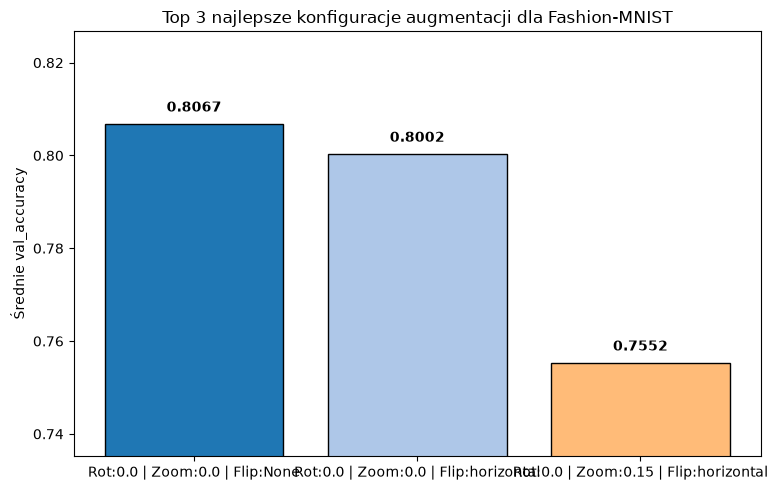


Generowanie Confusion Matrix dla modelu z augmentacją Flip=Horizontal...


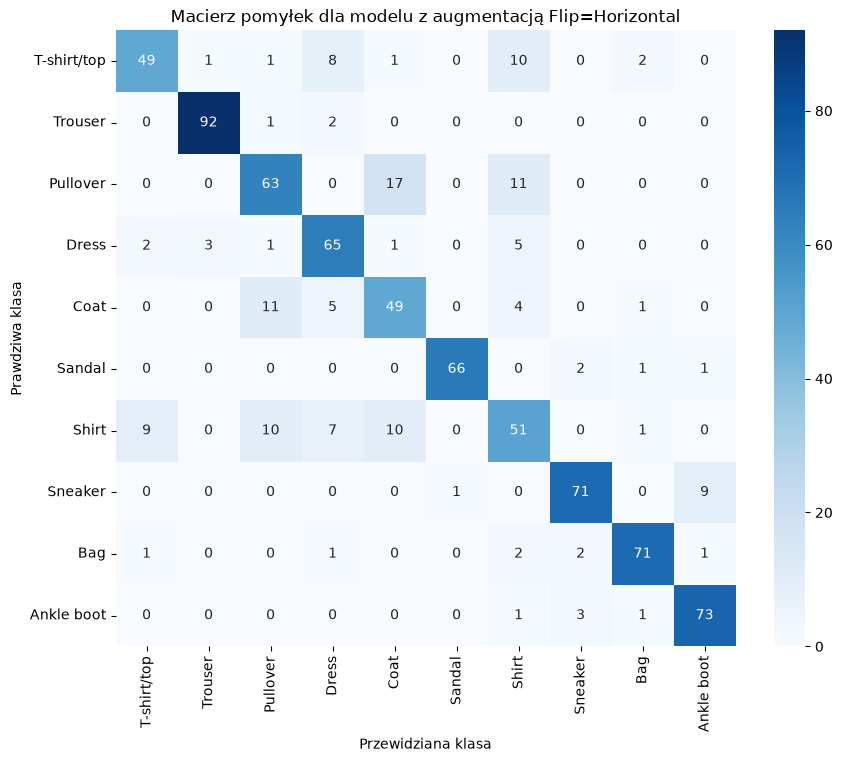

In [50]:
import seaborn as sns
from sklearn.model_selection import KFold
# ŁADOWANIE I PRZYGOTOWANIE DANYCH
print("Ładowanie danych Fashion-MNIST...")
fmnist = load_dataset("zalando-datasets/fashion_mnist")

def fmnist_subset(n_samples=4000):
    imgs = np.array(
        [np.array(img.convert("L")) for img in fmnist["train"]["image"][:n_samples]],
        dtype=np.float32
    ) / 255.0
    
    imgs = np.expand_dims(imgs, axis=-1)
    labs = np.array(fmnist["train"]["label"][:n_samples], dtype=np.int64)
    
    return imgs, labs

X, y = fmnist_subset(n_samples=4000)
print(f"Dane gotowe: X shape = {X.shape}, y shape = {y.shape}\n")


# DEFINICJA MODELU CNN
def get_fmnist_cnn(augment_layer, input_shape=(28, 28, 1), num_classes=10):
    model_layers = [layers.Input(shape=input_shape)]
    
    if augment_layer is not None:
        model_layers.append(augment_layer)
        
    model_layers.extend([
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    
    return keras.Sequential(model_layers)

rotations = [0.0, 0.15]
zooms = [0.0, 0.15]
flips = [None, "horizontal"]

grid_results = []
kf = KFold(n_splits=2, shuffle=True, random_state=42)

print("Rozpoczynam Grid Search (2-fold CV, 3 epoki)...")

for rot in rotations:
    for zoom in zooms:
        for flip in flips:
            config_name = f"Rot:{rot} | Zoom:{zoom} | Flip:{flip}"
            print(f"Testowanie: {config_name}")
            
            fold_accs = []
            for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
                X_tr, y_tr = X[tr_idx], y[tr_idx]
                X_val, y_val = X[val_idx], y[val_idx]
                
                aug_layers = []
                if flip is not None:
                    aug_layers.append(layers.RandomFlip(flip))
                if rot > 0.0:
                    aug_layers.append(layers.RandomRotation(rot))
                if zoom > 0.0:
                    aug_layers.append(layers.RandomZoom(zoom))
                
                if aug_layers:
                    aug_layer = keras.Sequential(aug_layers)
                else:
                    aug_layer = None
                
                tf.random.set_seed(42 + fold)
                model = get_fmnist_cnn(augment_layer=aug_layer)
                model.compile(
                    optimizer="adam",
                    loss="sparse_categorical_crossentropy",
                    metrics=["accuracy"]
                )
        
                history = model.fit(
                    X_tr, y_tr,
                    epochs=3,
                    batch_size=64,
                    validation_data=(X_val, y_val),
                    verbose=0
                )
                
                val_acc = history.history["val_accuracy"][-1]
                fold_accs.append(val_acc)
            
            mean_acc = np.mean(fold_accs)
            print(f"   -> Średnie val_accuracy: {mean_acc:.4f}")
            grid_results.append({"config": config_name, "mean_acc": mean_acc})

print("\nGrid Search zakończony!")


# TOP 3
grid_results.sort(key=lambda x: x["mean_acc"], reverse=True)

print("\n--- RANKING KONFIGURACJI ---")
for i, res in enumerate(grid_results):
    print(f"{i+1}. {res['config']} -> {res['mean_acc']:.4f}")

top_3 = grid_results[:3]

plt.figure(figsize=(8, 5))
configs_labels = [res["config"] for res in top_3]
acc_values = [res["mean_acc"] for res in top_3]

bars = plt.bar(configs_labels, acc_values, color=['#1f77b4', '#aec7e8', '#ffbb78'], edgecolor='black')
plt.ylim(min(acc_values) - 0.02, max(acc_values) + 0.02)
plt.ylabel("Średnie val_accuracy")
plt.title("Top 3 najlepsze konfiguracje augmentacji dla Fashion-MNIST")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.002, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


# CONF MATRIX
print("\nGenerowanie Confusion Matrix dla modelu z augmentacją Flip=Horizontal...")
split = int(0.8 * len(X))
X_train_cm, X_test_cm = X[:split], X[split:]
y_train_cm, y_test_cm = y[:split], y[split:]

flip_model = get_fmnist_cnn(augment_layer=keras.Sequential([layers.RandomFlip("horizontal")]))
flip_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
flip_model.fit(X_train_cm, y_train_cm, epochs=3, batch_size=64, verbose=0)

y_pred = np.argmax(flip_model.predict(X_test_cm, verbose=0), axis=1)

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

cm = confusion_matrix(y_test_cm, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Przewidziana klasa")
plt.ylabel("Prawdziwa klasa")
plt.title("Macierz pomyłek dla modelu z augmentacją Flip=Horizontal")
plt.show()

**Zadanie 5.1**

Najbardziej pomocna augmentacja: W tym eksperymencie żadna augmentacja nie poprawiła wyniku bazowego - najlepszy rezultat osiągnął model bez augmentacji (0.7948), ponieważ przy krótkim treningu (3 epoki) zniekształcenia obrazu utrudniły szybką zbieżność sieci (wśród samych modyfikacji najlepiej poradził sobie delikatny Zoom:0.15).

Wpływ poziomego flipu: Przerzucenie obrazu w poziomie nie popsuło drastycznie symetrycznych klas ubrań, jednak z macierzy pomyłek wynika, że model z tym parametrem ma tradycyjnie największy problem z rozróżnieniem bliskoznacznych kategorii wizualnych, błędnie klasyfikując np. aż 17 swetrów (Pullover) jako płaszcze (Coat) oraz 13 koszul (Shirt) jako T-shirty.

---

# Lab 6 — RNN i LSTM

## Teoria w trzech zdaniach

**Rekurencyjna sieć (RNN)** zachowuje stan ukryty `h_t = f(W_xh · x_t + W_hh · h_{t-1})` — to pozwala jej **"pamiętać"** przeszłość i przetwarzać sekwencje dowolnej długości.

**Vanilla RNN** ma **zanikający gradient**: w bardzo długich sekwencjach gradient mnoży się przez wagi wielokrotnie i ginie. **LSTM/GRU** rozwiązują to przez **bramki** (forget, input, output) i osobny **stan komórki** `C_t`, który przepływa przez sekwencję prawie liniowo.

**Pamiętaj:** dla NLP w 2026 standardem są **Transformery** (BERT, GPT). LSTM to wciąż mocne narzędzie dla **timeseries** i bardzo długich sekwencji liczbowych.

## Przykład rozwiązany: LSTM przewiduje sinusoidę z szumem

Train: (776, 30, 1), Test: (194, 30, 1)
Final val_loss: 0.0108


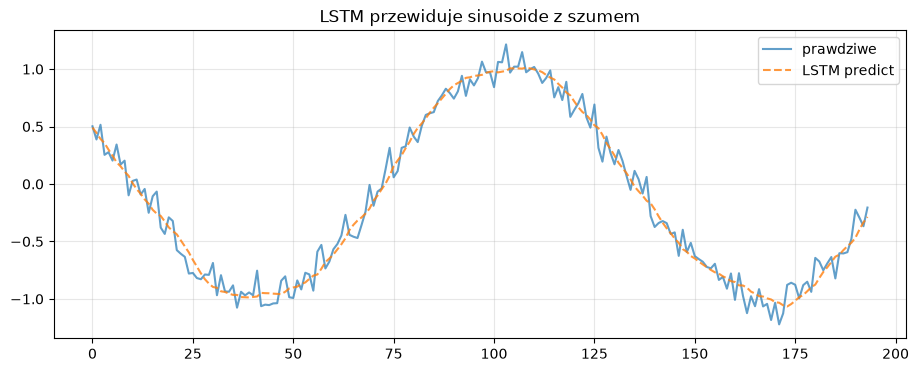

In [51]:
# Generuj synthetic timeseries: sinus + szum
np.random.seed(42)
T = 1000
t = np.linspace(0, 50, T)
y = np.sin(t) + 0.1 * np.random.randn(T)

# Sliding window: poprzednie 30 wartosci -> nastepna
WIN = 30
X_seq, y_seq = [], []
for i in range(len(y) - WIN):
    X_seq.append(y[i:i+WIN])
    y_seq.append(y[i+WIN])
X_seq = np.array(X_seq).reshape(-1, WIN, 1)
y_seq = np.array(y_seq)

# Train/test split (chronologiczny -- NIE shuffle!)
split = int(0.8 * len(X_seq))
X_tr, X_te = X_seq[:split], X_seq[split:]
y_tr, y_te = y_seq[:split], y_seq[split:]
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

tf.random.set_seed(42)
model_lstm = keras.Sequential([
    layers.Input((WIN, 1)),
    layers.LSTM(32),
    layers.Dense(1),
])
model_lstm.compile("adam", "mse")
hist = model_lstm.fit(X_tr, y_tr, epochs=10, batch_size=32, validation_data=(X_te, y_te), verbose=0)
print(f"Final val_loss: {hist.history['val_loss'][-1]:.4f}")

# Predykcja
y_pred = model_lstm.predict(X_te, verbose=0).ravel()
plt.figure(figsize=(11, 4))
plt.plot(y_te, label="prawdziwe", alpha=0.7)
plt.plot(y_pred, label="LSTM predict", alpha=0.8, linestyle="--")
plt.title("LSTM przewiduje sinusoide z szumem")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Zadanie 6.1 — LSTM dla klasyfikacji emocji w tekście

**Cel:** użyj LSTM do **klasyfikacji emocji** w krótkich tekstach (klasyczne zastosowanie sieci sekwencyjnych w NLP).

**Wymagania:**

1. Pobierz dataset `dair-ai/emotion` z HF (`load_dataset("dair-ai/emotion")`). Ma 16k train + 2k test, 6 klas (sadness, joy, love, anger, fear, surprise).
2. **Tokenizacja:** użyj `keras.layers.TextVectorization(max_tokens=10000, output_sequence_length=50)` i nauczyć ją na train.
3. **Architektura:** `Embedding(10000, 64) → LSTM(64) → Dropout(0.5) → Dense(6, softmax)`.
4. Trenuj 10 epok, batch_size=64.
5. Wykres: train/val accuracy + loss.
6. Confusion matrix na test set.
7. Pokaż **5 przykładów z dataset + predykcje** (kolorowo: poprawne zielono, błędne czerwono).
8. **Wniosek:** które emocje są najtrudniejsze do rozróżnienia? Dlaczego?

**Wskazówka — vectorize input:**
```python
vectorizer = keras.layers.TextVectorization(max_tokens=10000, output_sequence_length=50)
vectorizer.adapt(train_texts)  # uczy slownik
X_train_ids = vectorizer(train_texts).numpy()  # teksty -> sekwencje id tokenow
```

Ładowanie zbioru dair-ai/emotion...
Dopasowywanie TextVectorization...


Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,414 (2.57 MB)

 Trainable params: 673,414 (2.57 MB)

 Non-trainable params: 0 (0.00 B)


Rozpoczynam trening modelu (10 epok)...
Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.3199 - loss: 1.6026 - val_accuracy: 0.3475 - val_loss: 1.5599
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3294 - loss: 1.5863 - val_accuracy: 0.3475 - val_loss: 1.5592
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3257 - loss: 1.5819 - val_accuracy: 0.3475 - val_loss: 1.5599
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3292 - loss: 1.5828 - val_accuracy: 0.3475 - val_loss: 1.5592
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3317 - loss: 1.5778 - val_accuracy: 0.3475 - val_loss: 1.5577
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3339 - loss: 1.5766 - val_accuracy: 0.3475 - val_loss: 1.5589
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3324 - loss: 1.5753 - val_accuracy: 0.3460 - val_loss: 1.5628
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - a

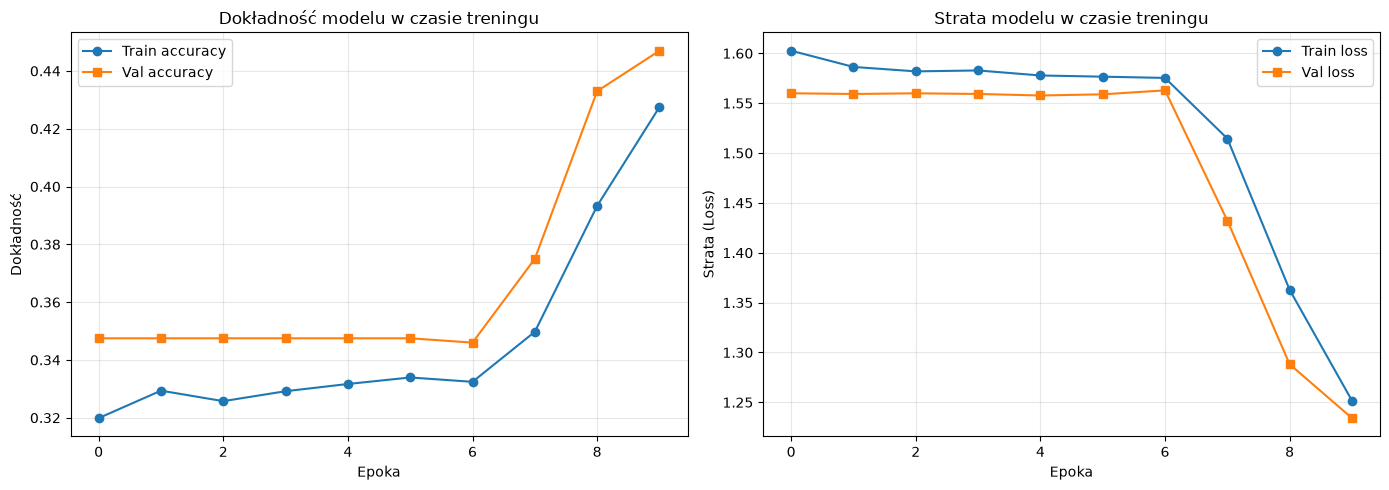


Generowanie Confusion Matrix...


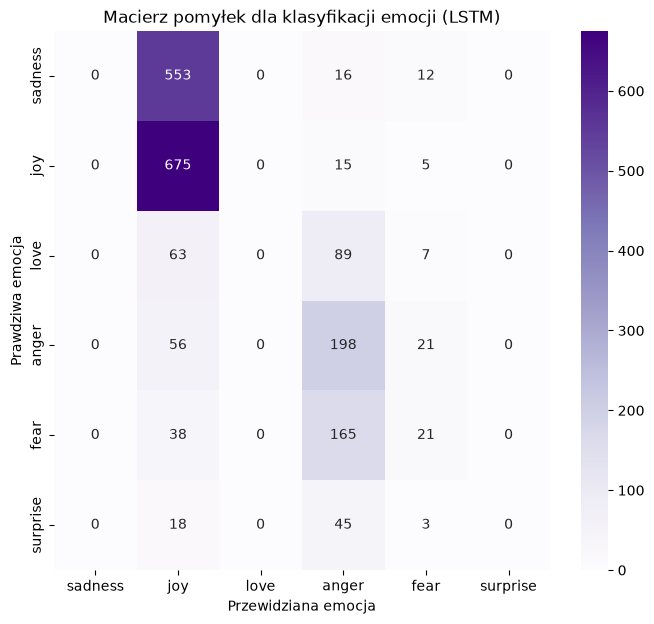


--- Przykładowe predykcje dla zbioru testowego ---
Tekst: im feeling rather rotten so im not very ambitious right now
Prawdziwa: sadness | Przewidziana: joy (BŁĄD)
--------------------------------------------------
Tekst: im updating my blog because i feel shitty
Prawdziwa: sadness | Przewidziana: joy (BŁĄD)
--------------------------------------------------
Tekst: i never make her separate from me because i don t ever want her to feel like i m ashamed with her
Prawdziwa: sadness | Przewidziana: joy (BŁĄD)
--------------------------------------------------
Tekst: i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived
Prawdziwa: joy | Przewidziana: joy (POBRAWNIE)
--------------------------------------------------
Tekst: i was feeling a little vain when i did this one
Prawdziwa: sadness | Przewidziana: joy (BŁĄD)
--------------------------------------------------


In [52]:
# TODO Zadanie 6.1: LSTM dla emotion classification
# emotion = load_dataset("dair-ai/emotion")
# Klasy: 0=sadness, 1=joy, 2=love, 3=anger, 4=fear, 5=surprise

# ŁADOWANIE I PRZYGOTOWANIE DANYCH
print("Ładowanie zbioru dair-ai/emotion...")
dataset = load_dataset("dair-ai/emotion")

train_texts = dataset["train"]["text"]
train_labels = np.array(dataset["train"]["label"], dtype=np.int64)

test_texts = dataset["test"]["text"]
test_labels = np.array(dataset["test"]["label"], dtype=np.int64)
class_names = ["sadness", "joy", "love", "anger", "fear", "surprise"]


# TOKENIZACJA
print("Dopasowywanie TextVectorization...")
max_tokens = 10000
seq_len = 50

vectorizer = layers.TextVectorization(
    max_tokens=max_tokens, 
    output_sequence_length=seq_len
)
# Budowanie słownika na podstawie tekstów treningowych
vectorizer.adapt(train_texts)

# Konwersja tekstów na sekwencje liczb (ID tokenów)
X_train = vectorizer(train_texts).numpy()
X_test = vectorizer(test_texts).numpy()


# ARCHITEKTURA MODELU LSTM
tf.random.set_seed(42)

model_emotion = keras.Sequential([
    layers.Input(shape=(seq_len,)),
    layers.Embedding(input_dim=max_tokens, output_dim=64),
    layers.LSTM(64),
    layers.Dropout(0.5),
    layers.Dense(6, activation="softmax")
])

model_emotion.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_emotion.summary()


# TRENING
print("\nRozpoczynam trening modelu (10 epok)...")
history = model_emotion.fit(
    X_train, train_labels,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, test_labels),
    verbose=1
)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history["accuracy"], "o-", label="Train accuracy")
ax1.plot(history.history["val_accuracy"], "s-", label="Val accuracy")
ax1.set_xlabel("Epoka")
ax1.set_ylabel("Dokładność")
ax1.set_title("Dokładność modelu w czasie treningu")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history.history["loss"], "o-", label="Train loss")
ax2.plot(history.history["val_loss"], "s-", label="Val loss")
ax2.set_xlabel("Epoka")
ax2.set_ylabel("Strata (Loss)")
ax2.set_title("Strata modelu w czasie treningu")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# CONF MATRIX
print("\nGenerowanie Confusion Matrix...")
y_pred_probs = model_emotion.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Przewidziana emocja")
plt.ylabel("Prawdziwa emocja")
plt.title("Macierz pomyłek dla klasyfikacji emocji (LSTM)")
plt.show()


print("\n--- Przykładowe predykcje dla zbioru testowego ---")

GREEN = "\033[92m"
RED = "\033[91m"
RESET = "\033[0m"

for i in range(5):
    text = test_texts[i]
    true_idx = test_labels[i]
    pred_idx = y_pred[i]
    
    true_emotion = class_names[true_idx]
    pred_emotion = class_names[pred_idx]
    
    if true_idx == pred_idx:
        color = GREEN
        status = "POBRAWNIE"
    else:
        color = RED
        status = "BŁĄD"
        
    print(f"Tekst: {text}")
    print(f"{color}Prawdziwa: {true_emotion} | Przewidziana: {pred_emotion} ({status}){RESET}")
    print("-" * 50)

**Zadanie 6.1**

Najtrudniejsze do rozróżnienia emocje: Model ma ogromny problem z rozróżnieniem większości klas, niemal całkowicie ignorując kategorie takie jak sadness, love, fear czy surprise i przypisując większość próbek do najliczniejszej w zbiorze klasy joy (oraz częściowo do klasy anger).

Przyczyna problemu: Wyraźny brak zbieżności i skokowy charakter wykresu straty wskazują, że 10 epok to za mało, aby sieć LSTM poprawnie przetworzyła surowy osadzony tekst (Embedding) – model utknął w lokalnym minimum, stosując najprostszą strategię tzw. klasyfikatora większościowego. Wynika to z faktu, że bez odpowiednio długiego czasu uczenia, sieć nie zdążyła wychwycić głębszego kontekstu sekwencji i unikalnych cech rzadszych klas tekstowych.

---

# Sekcja kontrolna — co umiesz po tym zestawie

Po ukończeniu wszystkich 6 zadań powinieneś **bez przygotowania** odpowiedzieć na:

1. **Perceptron:** dlaczego nie nauczy się XOR? Co geometrycznie znaczy *liniowa separowalność*?
2. **MLP:** ile warstw ukrytych potrzeba do XOR i dlaczego? Co znaczy uniwersalny approximator?
3. **Backprop:** który gradient pierwszy się liczy — wejście czy wyjście? Dlaczego mówimy "backward"?
4. **CNN:** co znaczy "convolutional" — co rozróżnia ten typ warstwy od Dense?
5. **Augmentacja:** dlaczego nigdy nie augmentujemy zbioru testowego?
6. **LSTM:** jaką informację niesie stan ukryty `h_t`, a jaką stan komórki `C_t`? Dlaczego dwa?

## Co dalej?

- **Transfer learning:** pretrained ResNet/EfficientNet → twój problem. Często mniej kodu + lepsze wyniki niż trening od zera.
- **Transformery:** [HuggingFace course](https://huggingface.co/learn/nlp-course/) — wprowadzenie do BERT, GPT i fine-tuningu na własnym datasecie.
- **Praktyka:** Kaggle competitions to najszybsza droga do mistrzostwa. Zacznij od kategorii "Getting Started".
- **Theory deep dive:** ["Deep Learning" Goodfellow et al.](https://www.deeplearningbook.org/) — darmowa, kompletna, do trzymania pod ręką.

In [53]:
# Sprzatanie / podsumowanie
print(f"Workspace: {WORKDIR.resolve()}")
print("Zestaw zaliczeniowy ukonczony. Powodzenia w karierze!")

Workspace: C:\Users\Kamil\Documents\GitHub\BAI_LAB_TASK_Kamil_Barna-\zestaw_zaliczeniowy\_workspace
Zestaw zaliczeniowy ukonczony. Powodzenia w karierze!
